# 🏠 House Price Prediction
**Task:** Regression pipeline to predict house prices using feature engineering & ensemble models  
**Models:** Linear Regression · Ridge · Random Forest · Gradient Boosting  
**Dataset:** [Kaggle – House Price Prediction](https://www.kaggle.com/datasets/bhanupratapbiswas/house-price-prediction)  
**Author:** AI Researcher | InternSpark Task Submission


## 0. Setup

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import joblib, warnings; warnings.filterwarnings('ignore')
print('Libraries loaded ✓')


## 1. Load & Clean

In [ ]:
df = pd.read_csv('data.csv')
print(f'Raw shape: {df.shape}')
print(df.isnull().sum())
# Remove bad rows: price=0, bedrooms=0
df = df[(df['price']>0) & (df['bedrooms']>0)].copy()
print(f'Clean shape: {df.shape}')
df.describe().round(2)


## 2. Exploratory Data Analysis

### 2.1 Price Distribution — Raw vs Log Transform

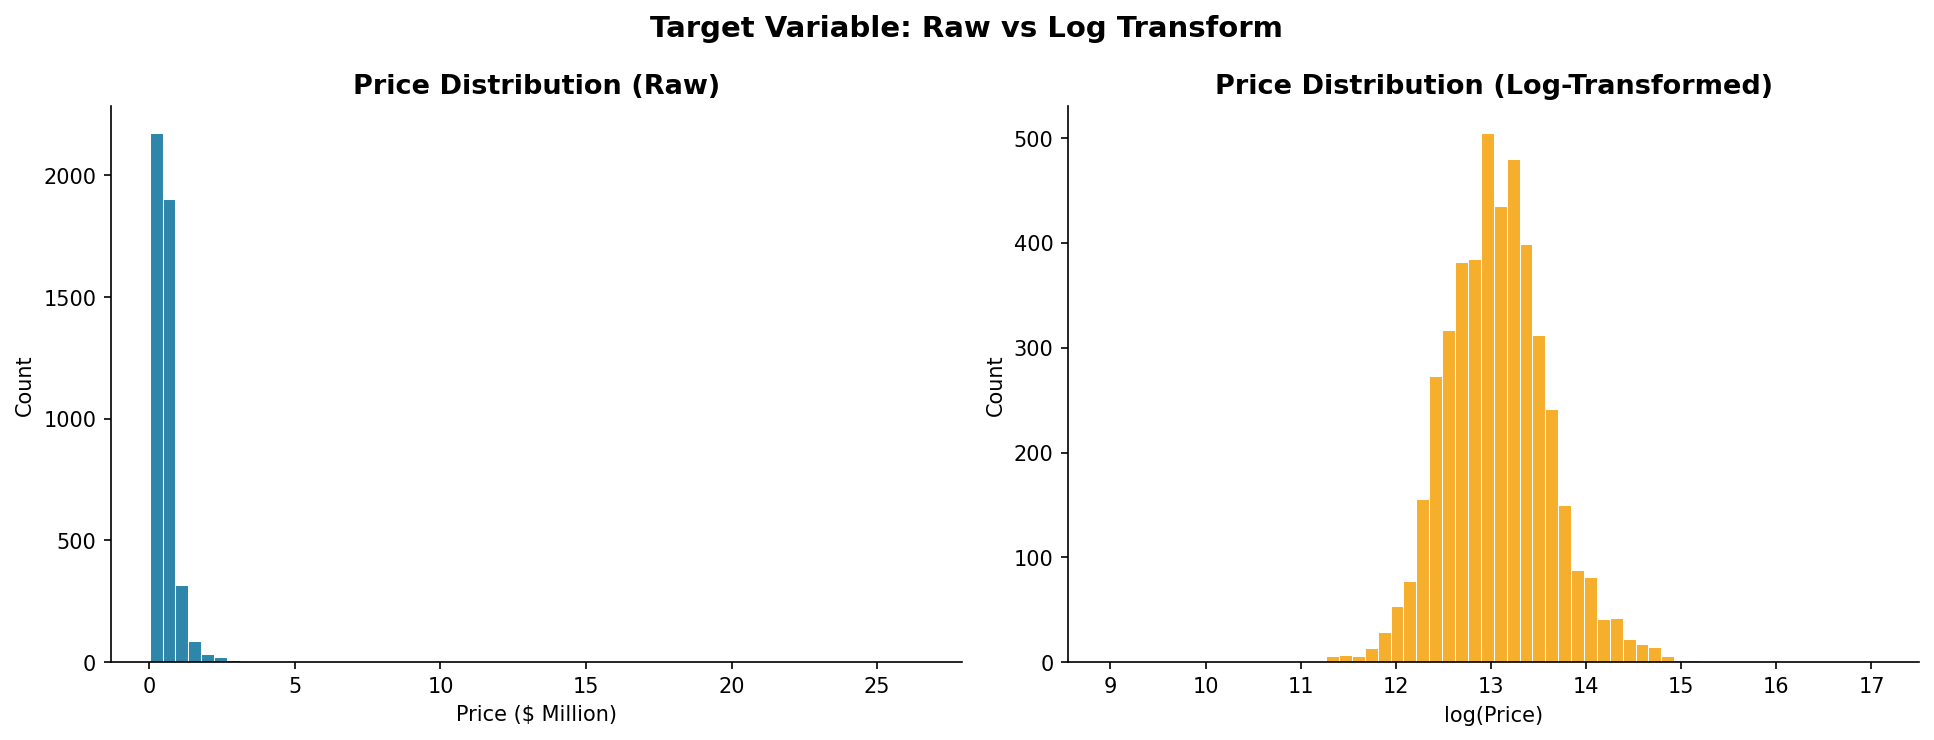

In [ ]:
# Price Distribution

### 2.2 Correlation Matrix

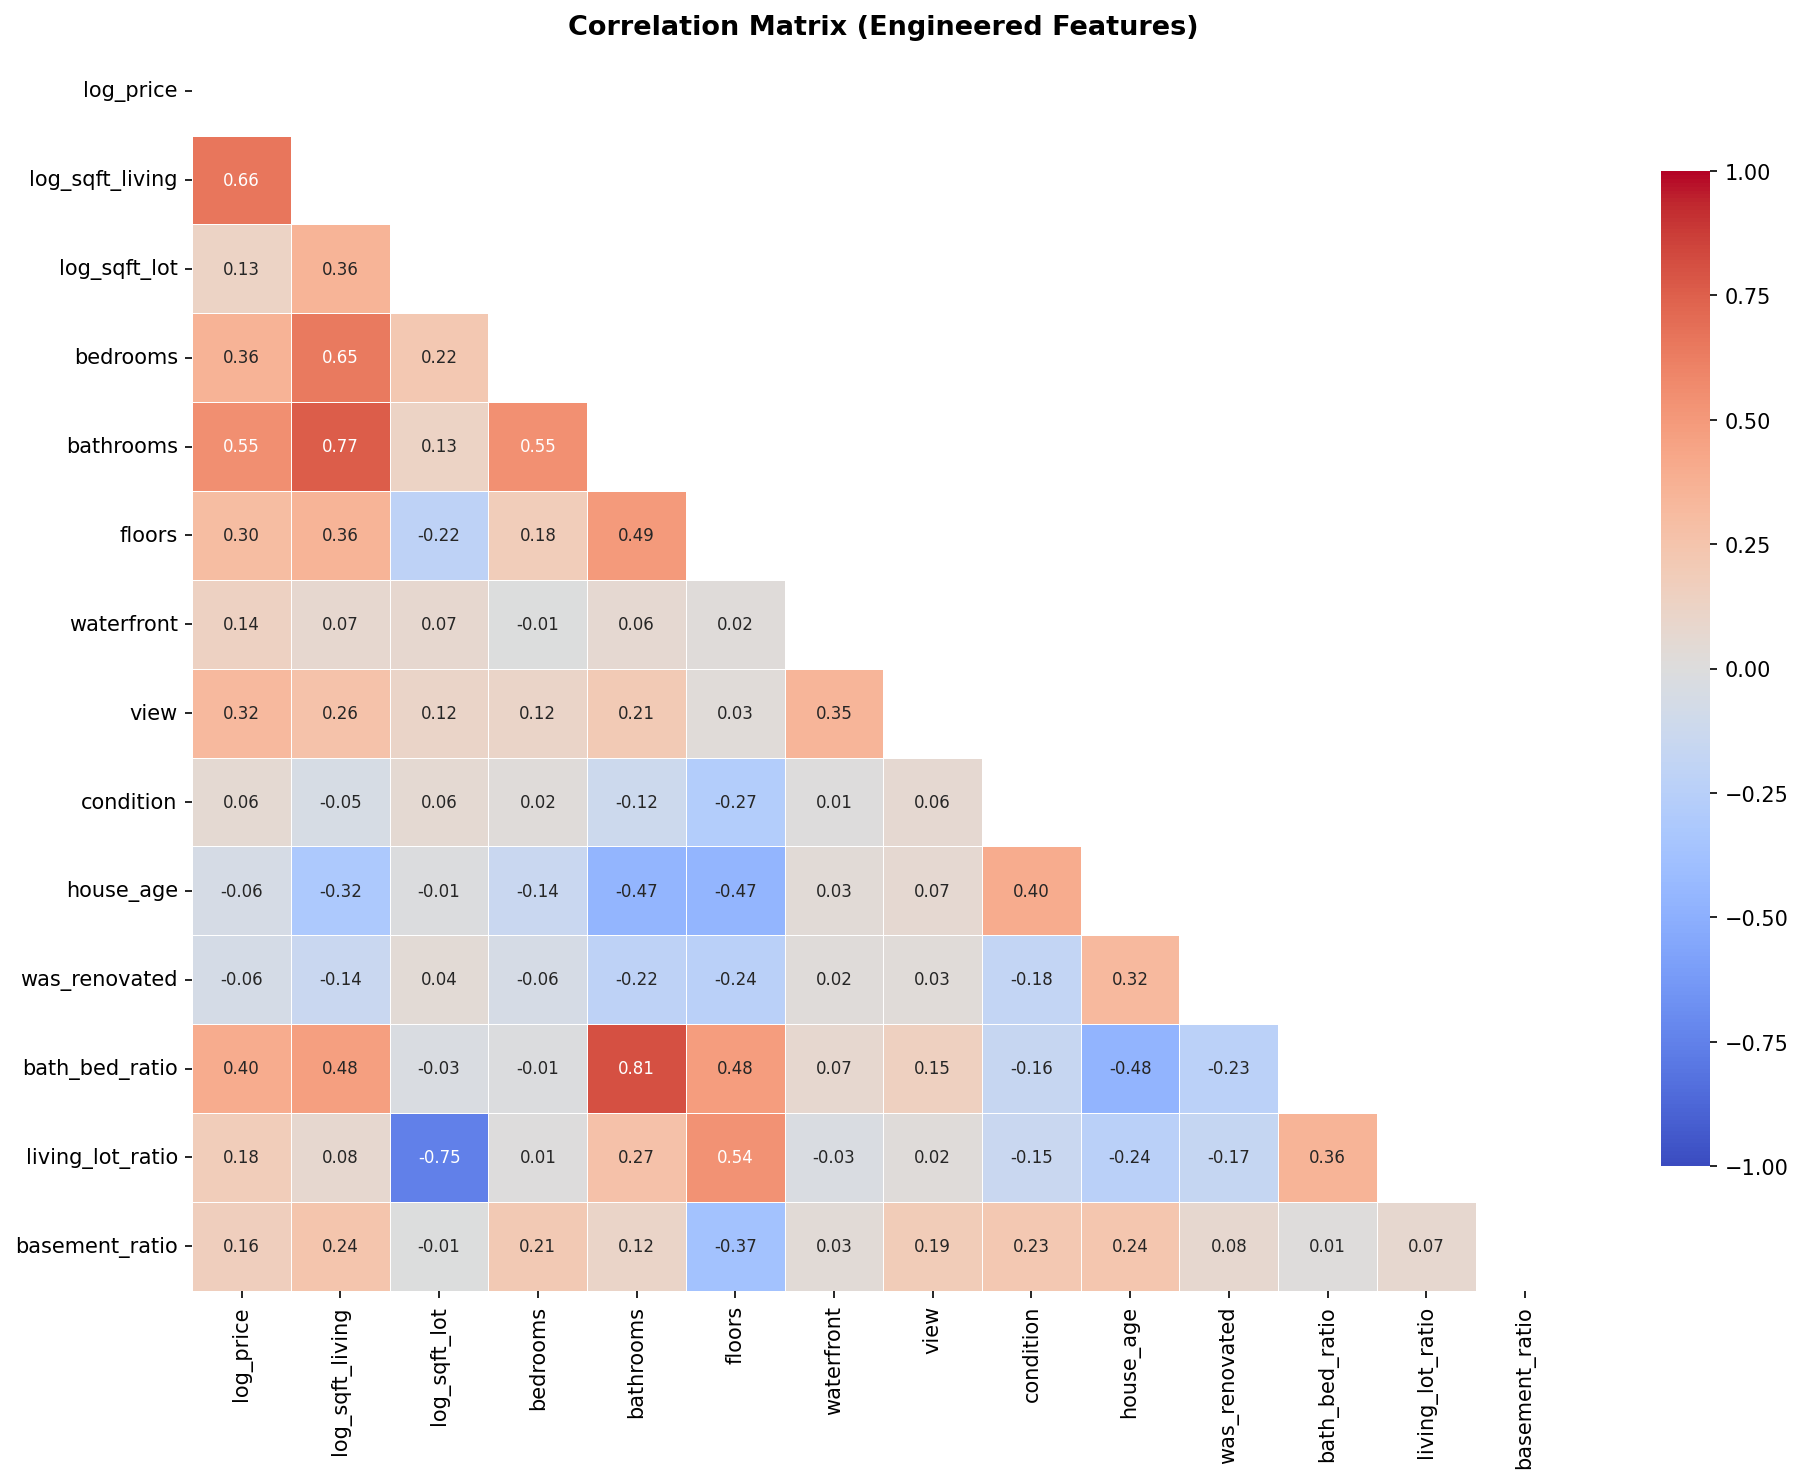

In [ ]:
# Correlation Heatmap

### 2.3 Key Feature Scatter Plots

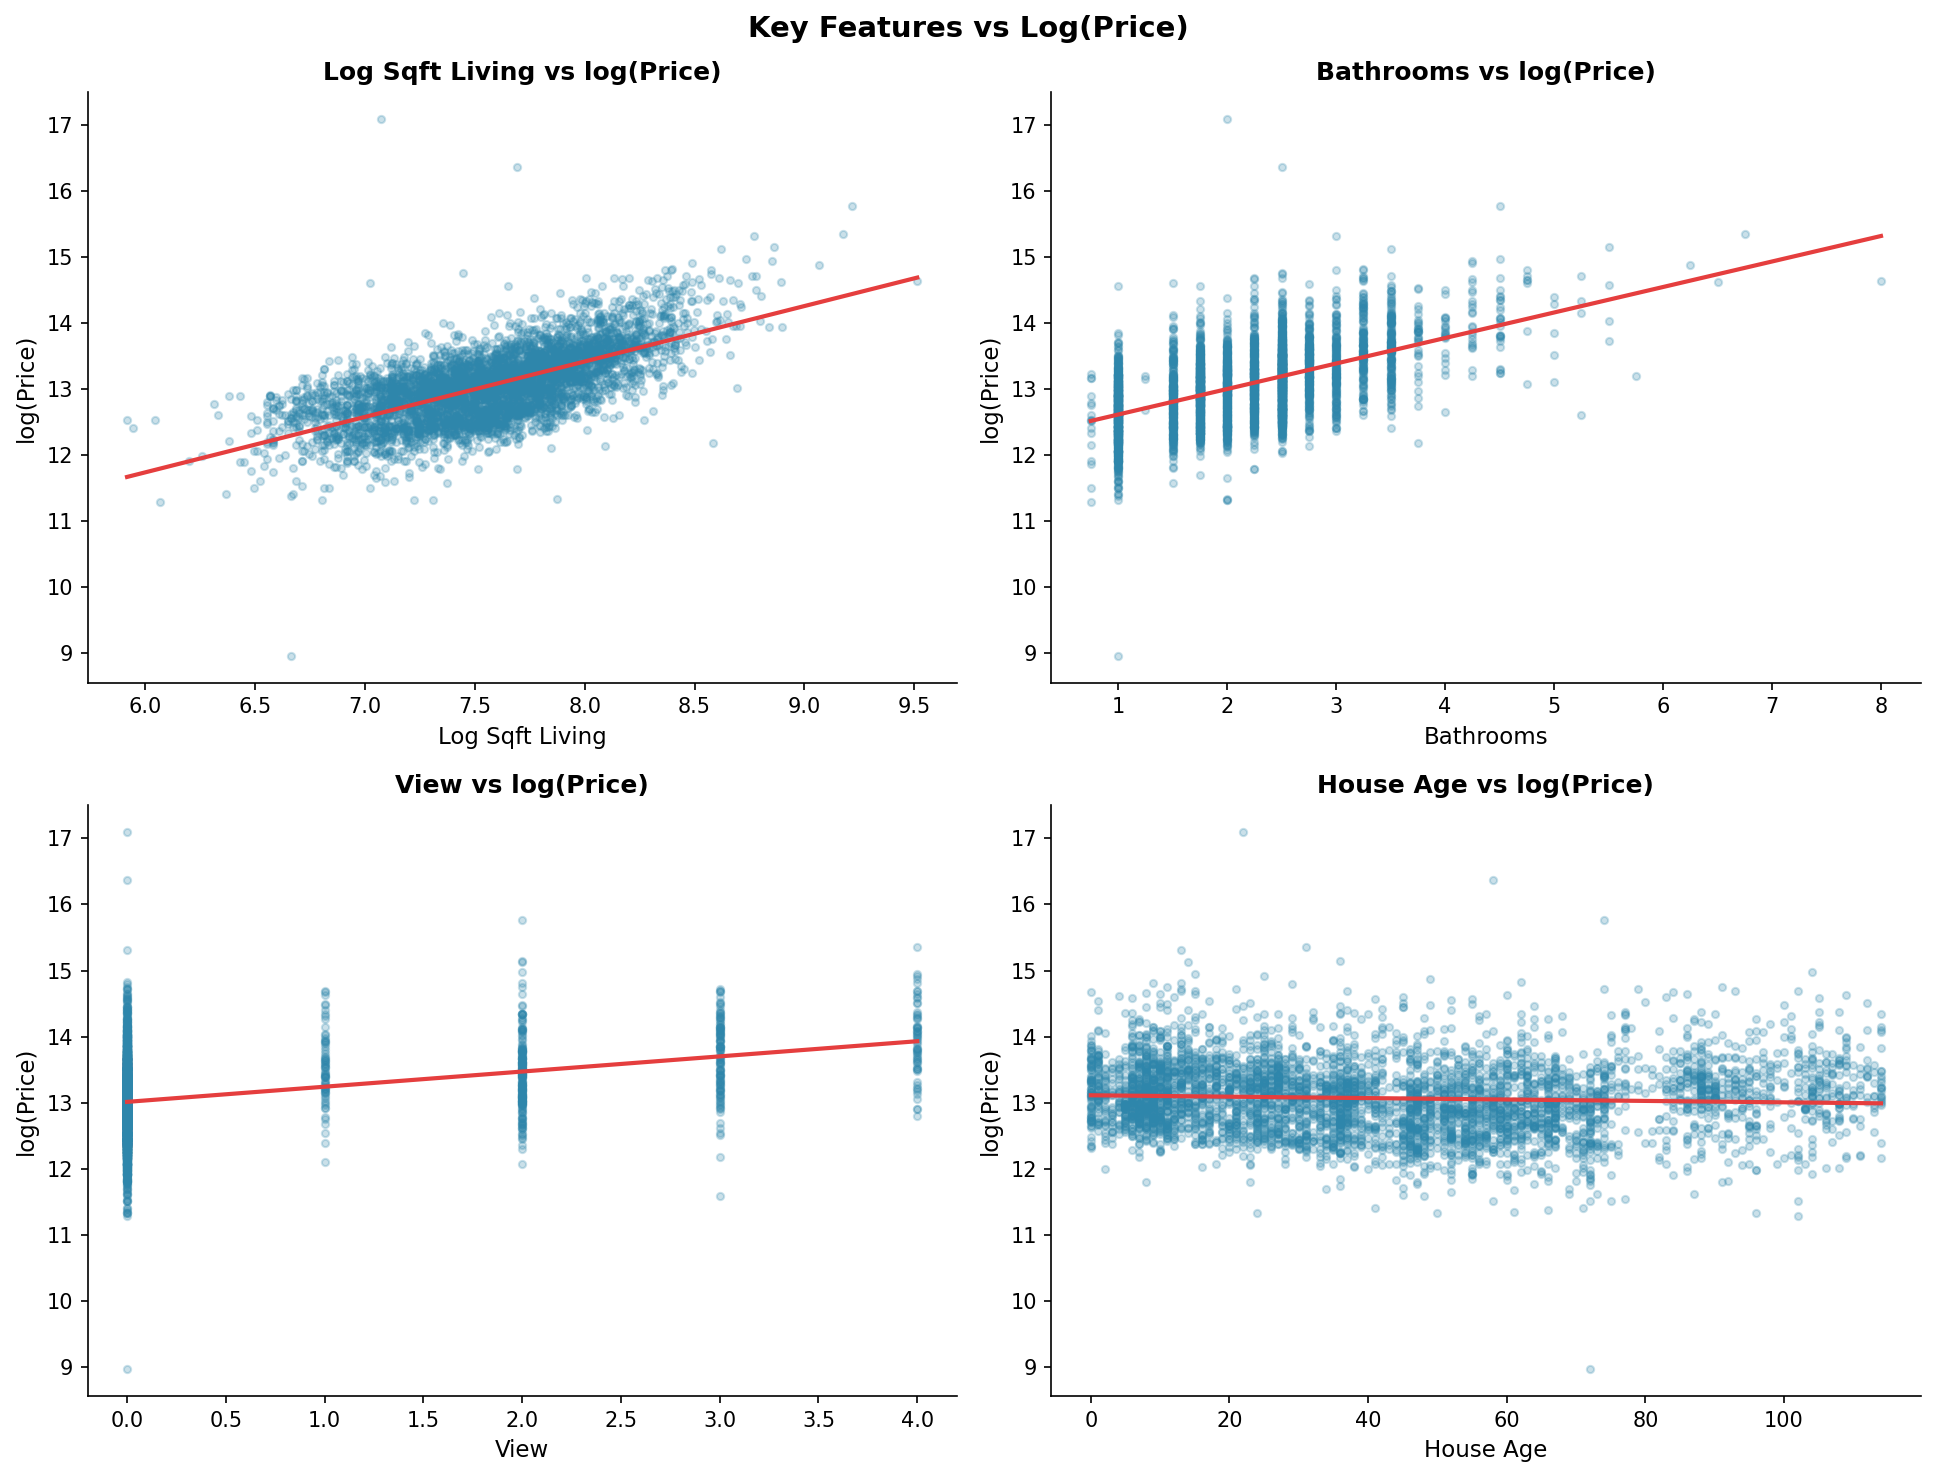

In [ ]:
# Feature Scatters

### 2.4 Median Price by City

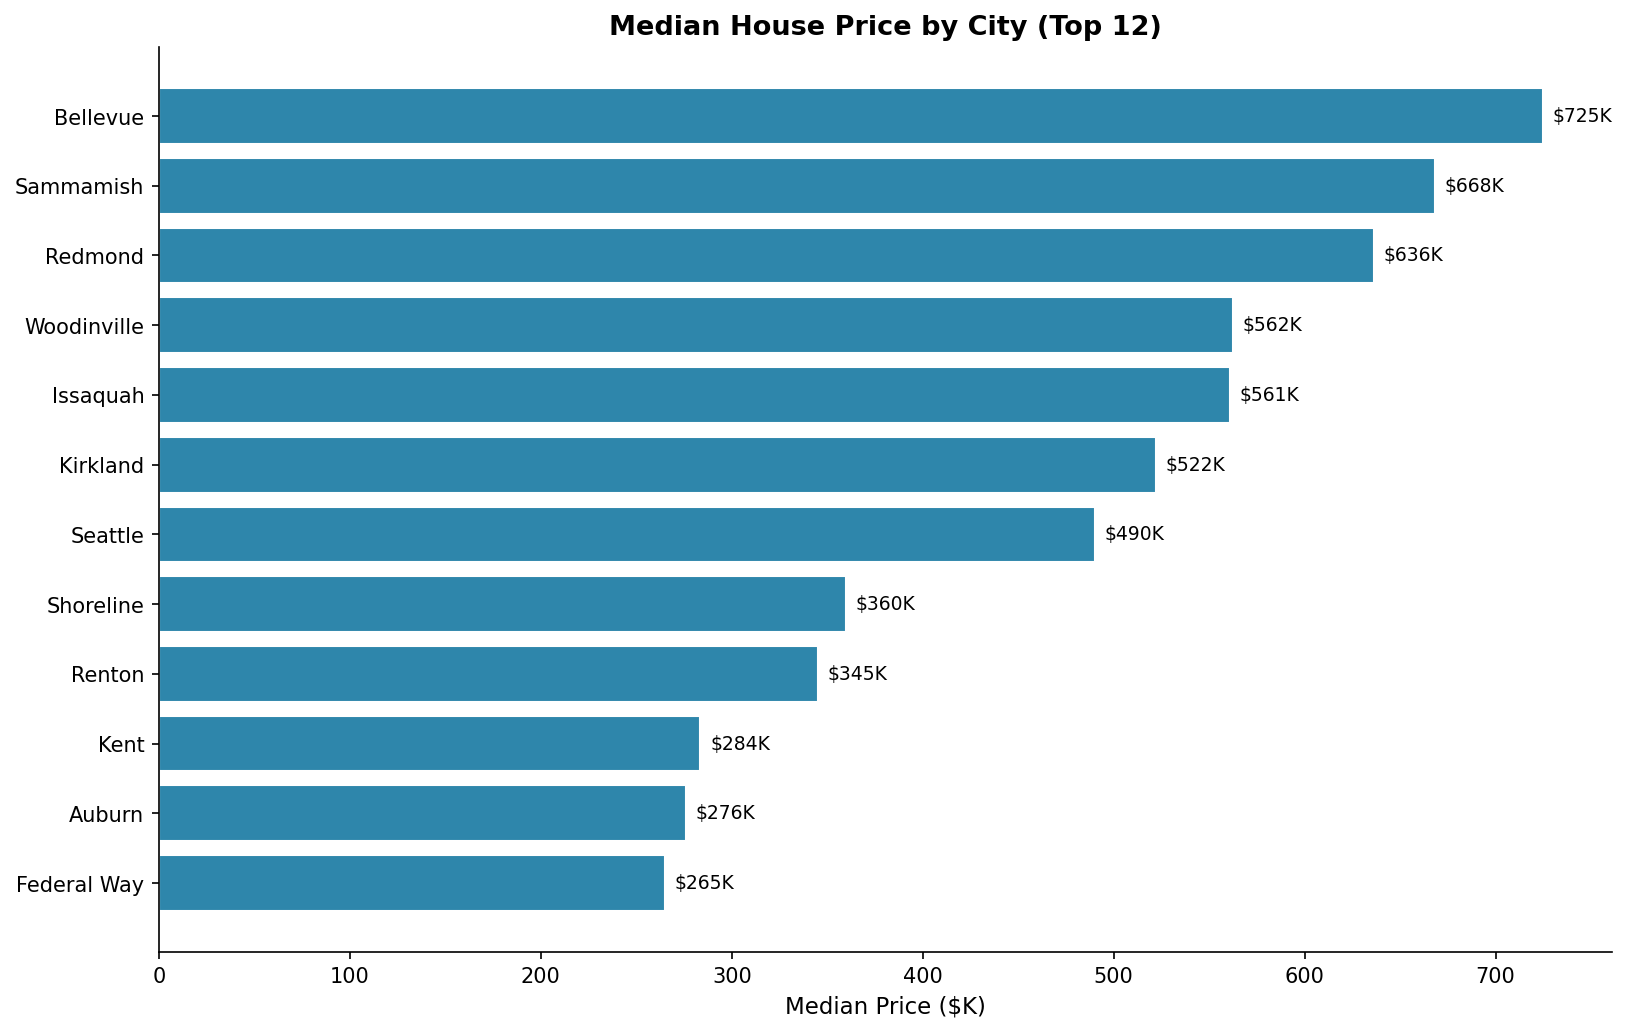

In [ ]:
# City Prices

### 2.5 Price vs Sqft Living (Condition)

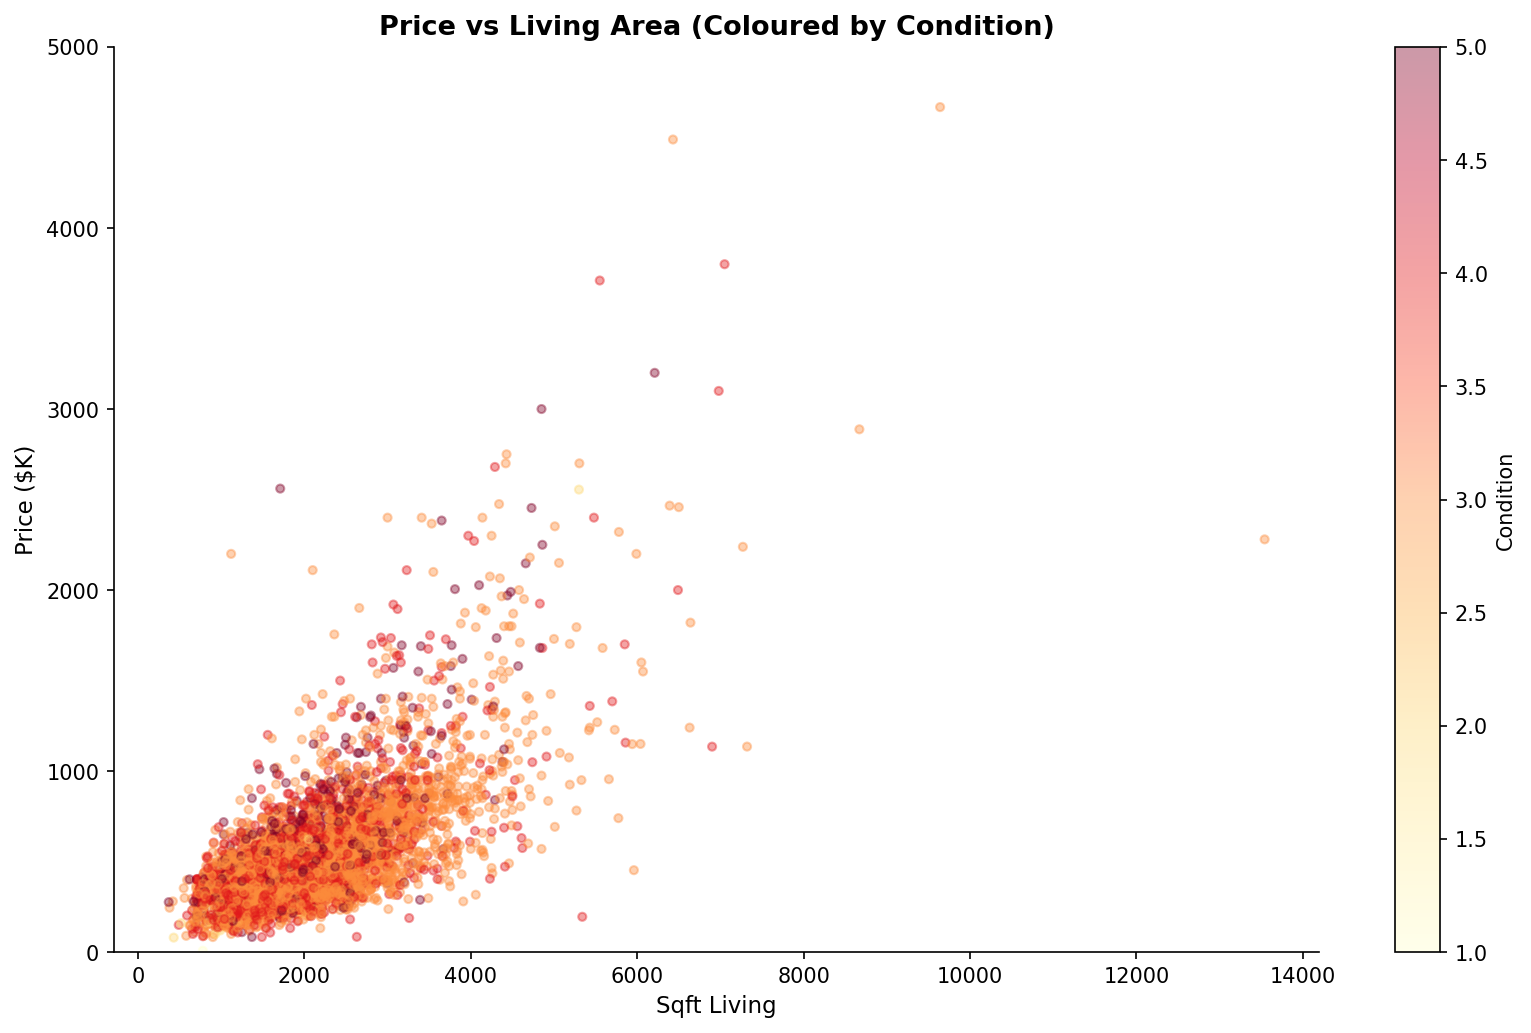

In [ ]:
# Sqft vs Price

### 2.6 Outlier Detection

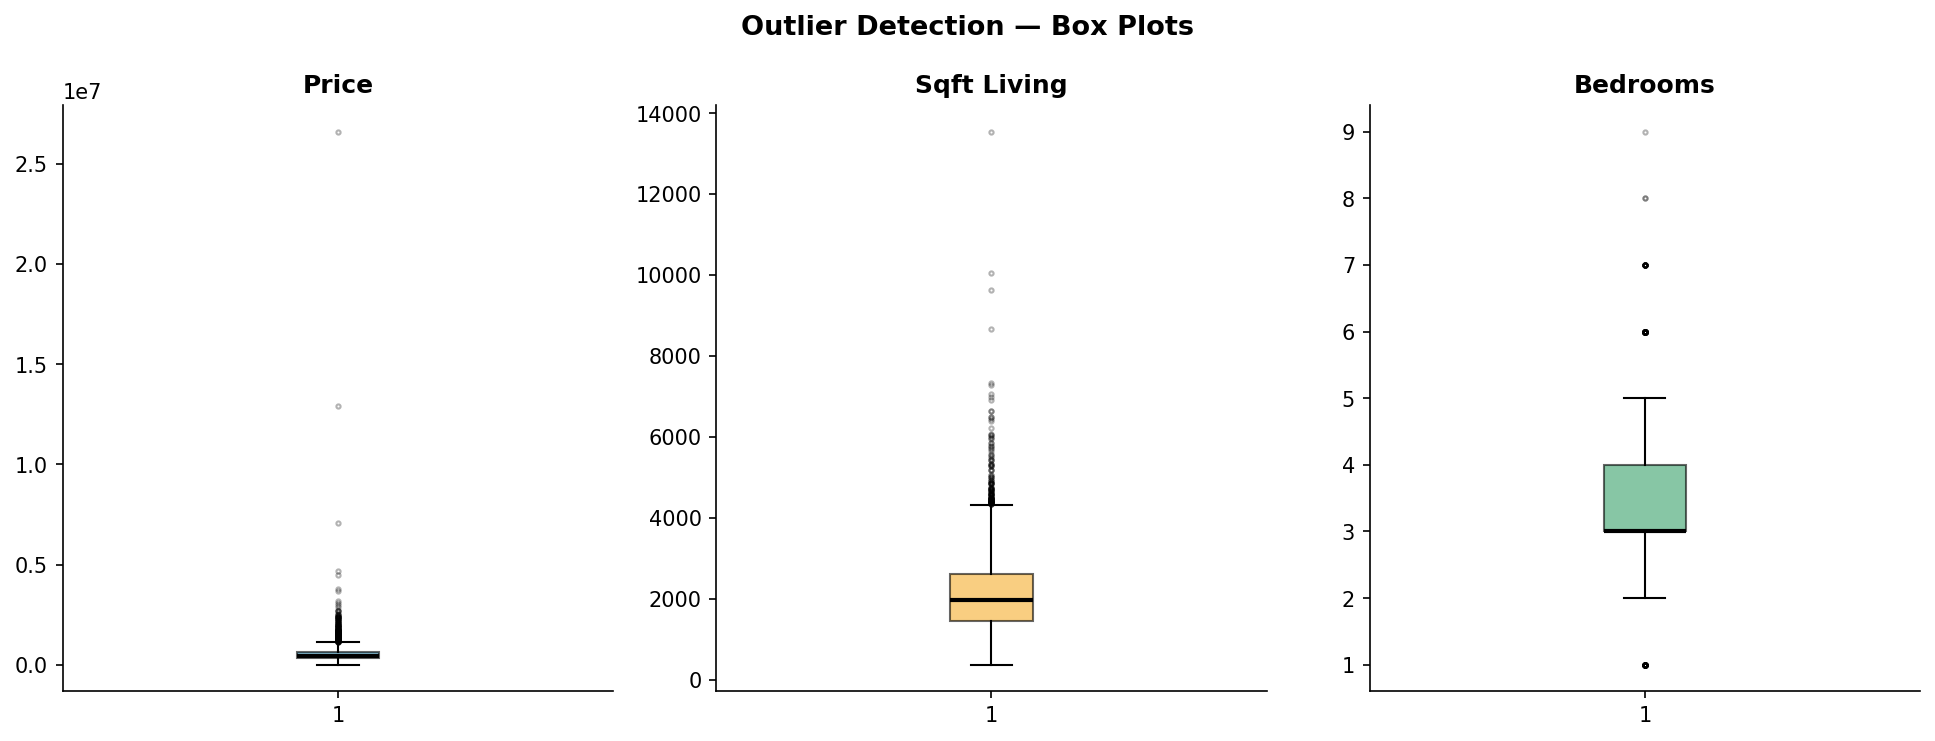

In [ ]:
# Box Plots

## 3. Feature Engineering

| Feature | Description |
|---|---|
| `log_sqft_living` | Log-transform of living area (reduces right skew) |
| `log_sqft_lot` | Log-transform of lot area |
| `house_age` | `sale_year - yr_built` |
| `was_renovated` | Binary flag: 1 if ever renovated |
| `years_since_reno` | Years since last renovation (0 if never) |
| `bath_bed_ratio` | Bathrooms / (Bedrooms+1) |
| `living_lot_ratio` | sqft_living / sqft_lot |
| `basement_ratio` | sqft_basement / sqft_living |
| `city_enc` | Label-encoded city (top 20 + Other) |
| `sale_month` | Month of sale (seasonality) |


In [ ]:
df['date']         = pd.to_datetime(df['date'])
df['sale_year']    = df['date'].dt.year
df['sale_month']   = df['date'].dt.month
df['house_age']    = df['sale_year'] - df['yr_built']
df['was_renovated']= (df['yr_renovated']>0).astype(int)
df['years_since_reno'] = np.where(df['yr_renovated']>0, df['sale_year']-df['yr_renovated'],0)
df['total_sqft']   = df['sqft_living'] + df['sqft_lot']
df['basement_ratio']   = df['sqft_basement']/(df['sqft_living']+1)
df['bath_bed_ratio']   = df['bathrooms']/(df['bedrooms']+1)
df['living_lot_ratio'] = df['sqft_living']/(df['sqft_lot']+1)
top_cities = df['city'].value_counts().nlargest(20).index
df['city_enc'] = df['city'].where(df['city'].isin(top_cities),'Other')
le = LabelEncoder(); df['city_enc'] = le.fit_transform(df['city_enc'])
df['log_price']       = np.log1p(df['price'])
df['log_sqft_living'] = np.log1p(df['sqft_living'])
df['log_sqft_lot']    = np.log1p(df['sqft_lot'])
df['log_total_sqft']  = np.log1p(df['total_sqft'])
print('Features created ✓')


## 4. Model Training & Evaluation

In [ ]:
FEATURES = ['log_sqft_living','log_sqft_lot','bedrooms','bathrooms','floors',
            'waterfront','view','condition','sqft_above','sqft_basement',
            'house_age','was_renovated','years_since_reno',
            'bath_bed_ratio','living_lot_ratio','basement_ratio',
            'city_enc','sale_month']

X = df[FEATURES].values
y = df['log_price'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=10),
    'Random Forest':      RandomForestRegressor(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=300,learning_rate=0.08,max_depth=5,random_state=42),
}

cv = KFold(n_splits=5,shuffle=True,random_state=42)
results = {}
for name, clf in models.items():
    clf.fit(X_train_sc, y_train)
    yp  = np.expm1(clf.predict(X_test_sc))
    ytr = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(ytr,yp))
    mae  = mean_absolute_error(ytr,yp)
    r2   = r2_score(ytr,yp)
    cv_r2= cross_val_score(clf,X_train_sc,y_train,cv=cv,scoring='r2').mean()
    results[name]=dict(clf=clf,yp=yp,rmse=rmse,mae=mae,r2=r2,cv_r2=cv_r2)
    print(f'{name}: RMSE=${rmse:,.0f}  MAE=${mae:,.0f}  R²={r2:.4f}  CV_R²={cv_r2:.4f}')


### 4.1 Model Comparison

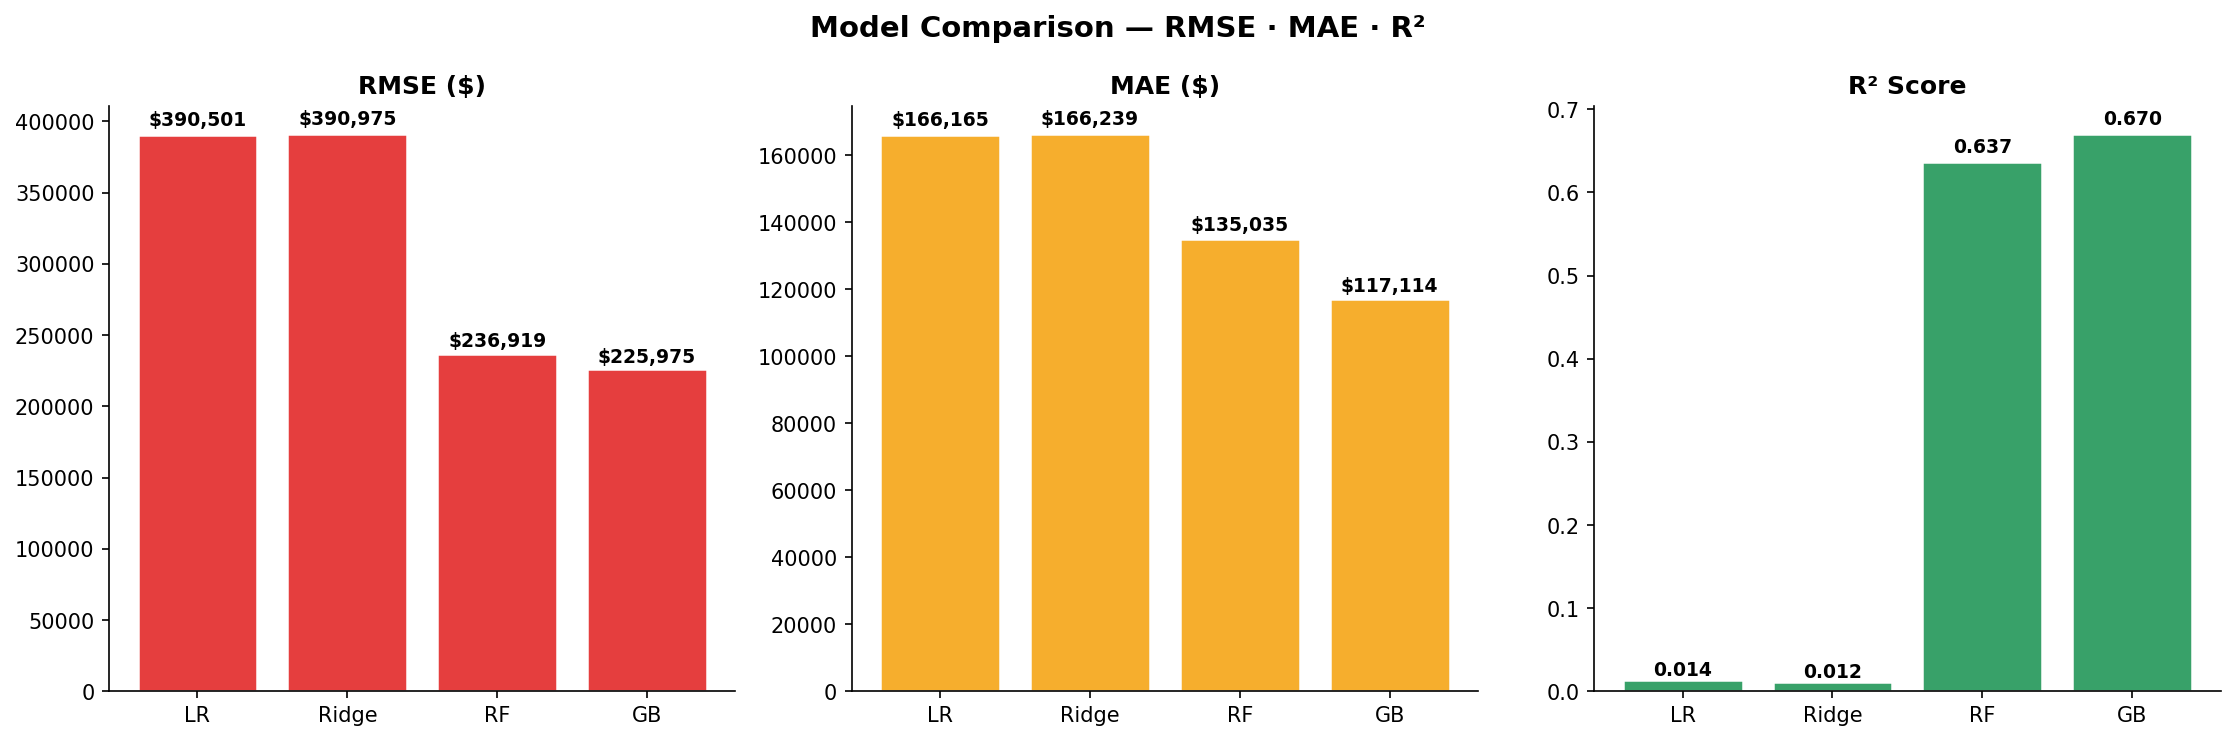

In [ ]:
# Model Comparison

### 4.2 Actual vs Predicted

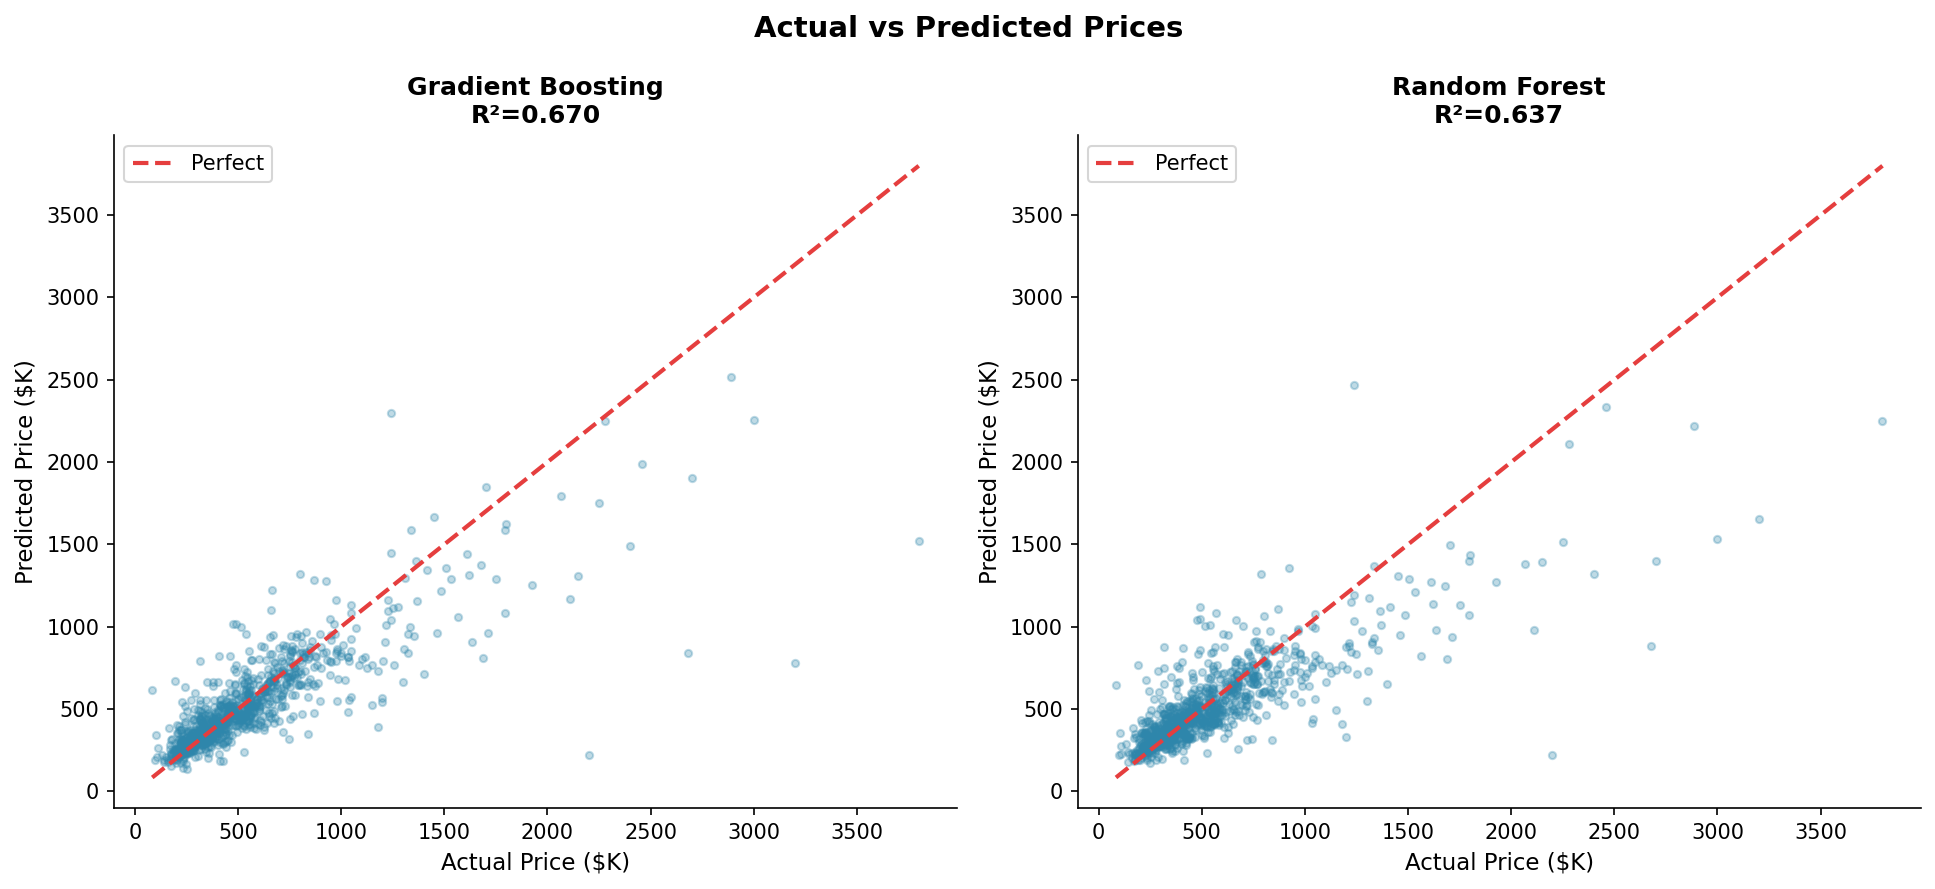

In [ ]:
# Actual vs Predicted

### 4.3 Residual Analysis

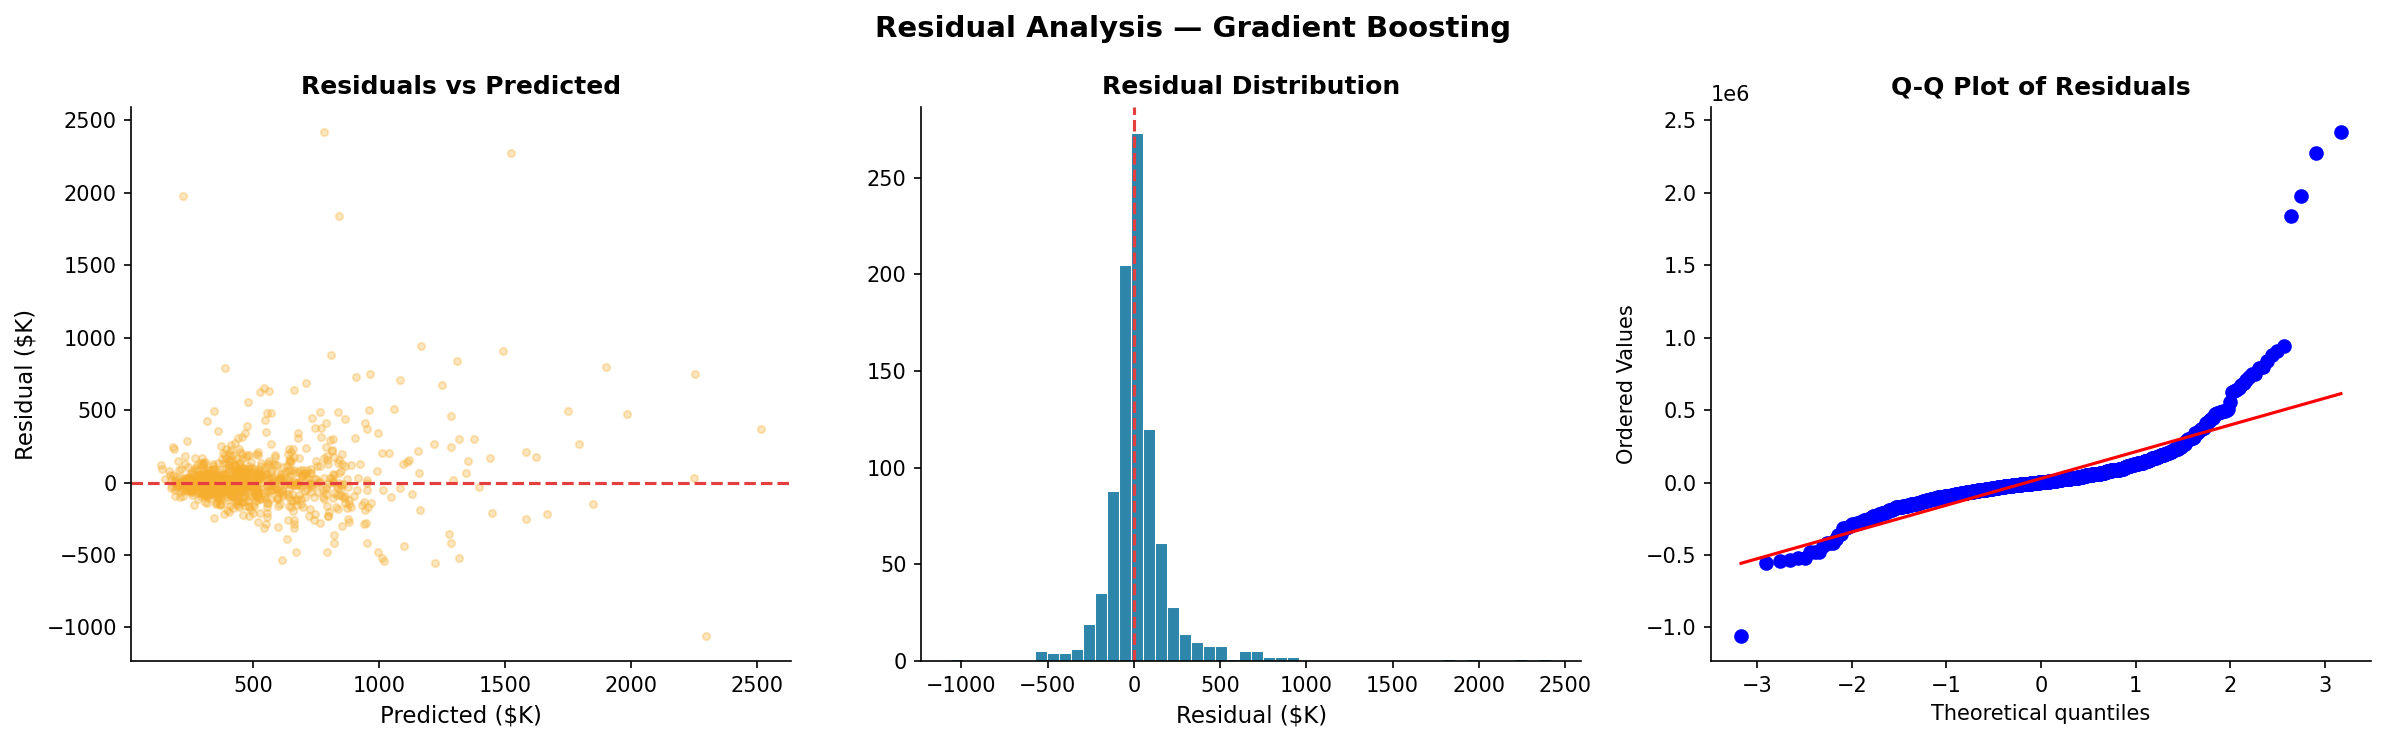

In [ ]:
# Residuals

### 4.4 Feature Importances (Random Forest)

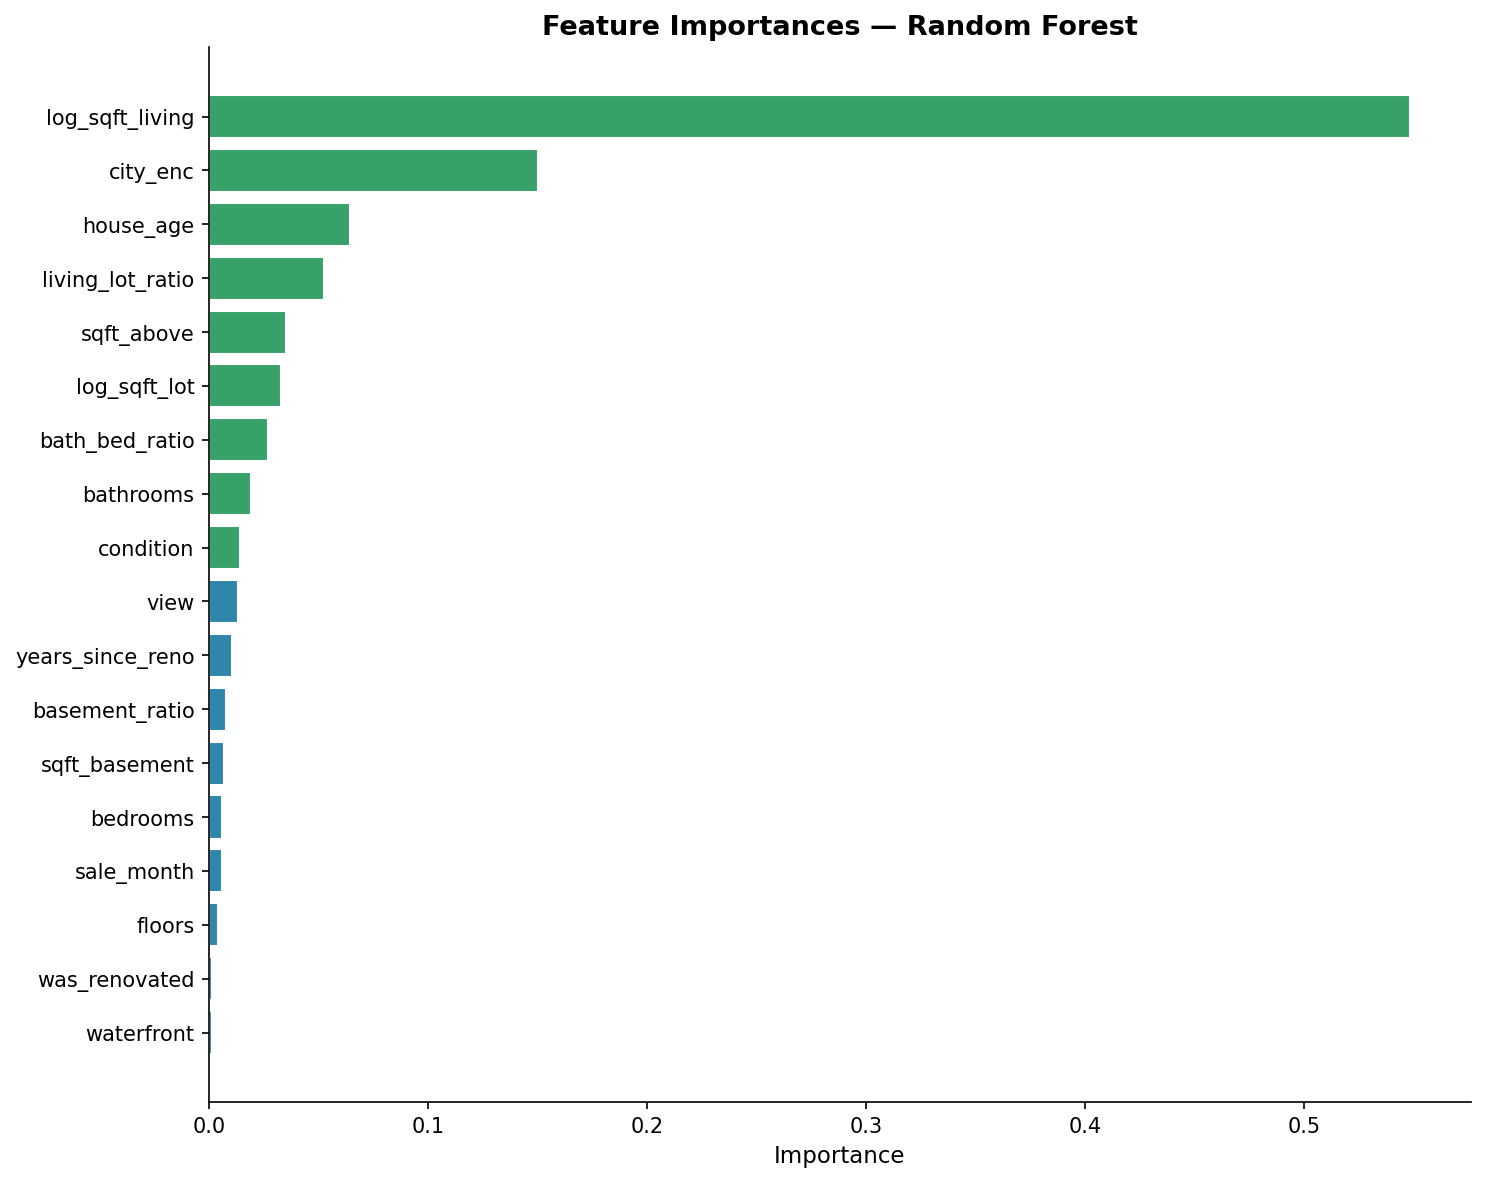

In [ ]:
# Feature Importances

## 5. Save Best Model

In [ ]:
best_name = max(results, key=lambda n: results[n]['r2'])
print(f'Best model: {best_name}  R²={results[best_name]["r2"]:.4f}')

bundle = {'model': results[best_name]['clf'], 'scaler': scaler,
          'feature_names': FEATURES, 'target': 'log_price',
          'best_model_name': best_name}
joblib.dump(bundle, 'house_price_best_model.joblib')
print('Saved house_price_best_model.joblib ✓')


## 6. Inference Example

In [ ]:
bundle   = joblib.load('house_price_best_model.joblib')
clf      = bundle['model']
scaler   = bundle['scaler']
features = bundle['feature_names']

# Example house: 3 bed, 2 bath, 1800 sqft, built 1990, Seattle
sample = pd.DataFrame([{
    'log_sqft_living': np.log1p(1800), 'log_sqft_lot': np.log1p(5000),
    'bedrooms': 3,    'bathrooms': 2,  'floors': 1,
    'waterfront': 0,  'view': 0,       'condition': 3,
    'sqft_above': 1800, 'sqft_basement': 0,
    'house_age': 34,  'was_renovated': 0, 'years_since_reno': 0,
    'bath_bed_ratio': 2/4, 'living_lot_ratio': 1800/5000, 'basement_ratio': 0,
    'city_enc': 12,   'sale_month': 6,
}])[features]

pred_log = clf.predict(scaler.transform(sample))[0]
pred_price = np.expm1(pred_log)
print(f'Predicted Price: ${pred_price:,.0f}')
